Rats: 110 | Groups: 11 | Weeks: 15
Water groups: ['Group 1 (RO water with < 20 TDS)', 'Group 10 (Ground water collected form prakshnagar colony with Alternate day fasting', 'Group 11 (RO Water 125 - 150 TDS with alternate day fasting)', 'Group 2 (RO water with 50-75 TDS)', 'Group 3 (RO water with 125 - 150 TDS)', 'Group 4 (Telugu Ganga water supplied to Tirupati)', 'Group 5 (Kalyani Dam water supplied to Tirupati)', 'Group 6 (Ground water Collected for Prakash nagar cology, Tirupati)', 'Group 7 (RO water <20 with alternate day fasting (feed withdrawal))', 'Group 8 (Kalyani Dam water supplied to Tirupati with alternate day fasting (feed withdrawal))', 'Group 9 (water prepared as per BIS)']

REPEATED-MEASURES ANOVA — water_group × week
     Source            SS  DF1  DF2          MS          F         p-unc    p-GG-corr      np2      eps sphericity      W-spher  p-spher
water_group  28381.991515   10   99 2838.199152  27.239140  3.425305e-24          NaN 0.733435      NaN        NaN     

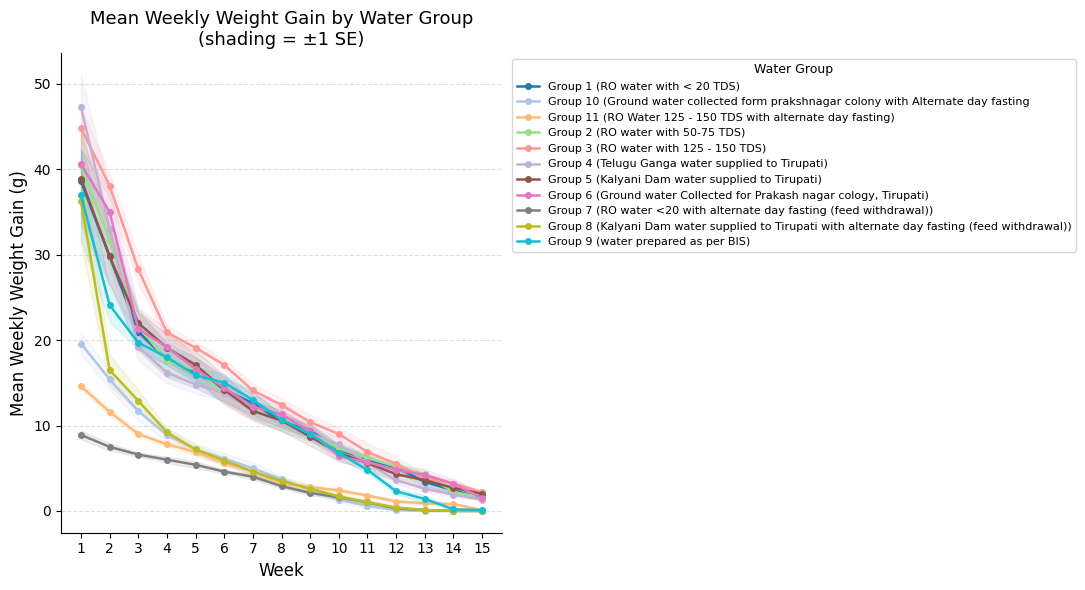

In [2]:
"""
Repeated-Measures ANOVA: Weekly Weight Gain by Water Group
==========================================================
Between-subject factor : water_group  (11 levels)
Within-subject factor  : week         (15 levels)
Optional between factor: gender
Dependent variable     : weekly_weight_gain
Subject ID             : unique_rat_id
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pingouin import mixed_anova, rm_anova, sphericity
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# 0.  LOAD YOUR DATA — adjust path as needed
# ─────────────────────────────────────────────
df = pd.read_csv("data/processed_rat_data.csv")   # <── change this

# ─────────────────────────────────────────────
# 1.  DATA PREPARATION
# ─────────────────────────────────────────────
df["water_group"] = df["water_group"].astype("category")
df["gender"]      = df["gender"].astype("category")
df["week"]        = df["week"].astype("category")       # categorical for ANOVA
df["week_int"]    = df["week"].cat.codes + 1            # integer copy for plotting

# Confirm structure
assert df.groupby(["unique_rat_id", "week"]).size().max() == 1, \
    "Duplicate rows detected for some rat-week combinations!"

n_rats   = df["unique_rat_id"].nunique()
n_groups = df["water_group"].nunique()
n_weeks  = df["week"].nunique()
print(f"Rats: {n_rats} | Groups: {n_groups} | Weeks: {n_weeks}")
print(f"Water groups: {sorted(df['water_group'].unique())}\n")

# ─────────────────────────────────────────────
# 2.  REPEATED-MEASURES ANOVA  (pingouin)
# ─────────────────────────────────────────────
# pingouin rm_anova expects long-format data.
# between= handles between-subject factors.

print("=" * 60)
print("REPEATED-MEASURES ANOVA — water_group × week")
print("=" * 60)

# Convert week back to int so pingouin treats it as within factor levels
df_anova = df.copy()
df_anova["week"] = df_anova["week_int"]   # pingouin needs numeric within-factor


# mixed_anova = between-subject factor + within-subject factor (repeated measures)
aov = mixed_anova(
    data    = df_anova,
    dv      = "weekly_weight_gain",
    within  = "week",
    between = "water_group",
    subject = "unique_rat_id",
    correction = True,   # Greenhouse-Geisser if sphericity violated
    effsize = "np2",
)

print(aov.to_string(index=False))
print()

# Extract key rows
def extract_effect(aov_table, label):
    mask = aov_table["Source"].str.contains(label, case=False)
    return aov_table[mask]

print("─" * 60)
print("SUMMARY OF MAIN EFFECTS & INTERACTION")
print("─" * 60)
for label in ["water_group", "week", "Interaction"]:
    row = extract_effect(aov, label)
    if row.empty:
        continue
    src  = row["Source"].values[0]
    F    = row["F"].values[0]
    p    = row["p-unc"].values[0]
    p_gc = row["p-GG-corr"].values[0] if "p-GG-corr" in row.columns else np.nan
    np2  = row["np2"].values[0] if "np2" in row.columns else np.nan
    sig  = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {src:<30}  F = {F:8.3f}  p = {p:.4f} {sig}  "
          f"p(GG) = {p_gc:.4f}  η²p = {np2:.4f}")

# ─────────────────────────────────────────────
# 2b.  OPTIONAL — Add gender as between factor
#      mixed_anova takes ONE between factor.
#      Combine water_group + gender into one.
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("MIXED ANOVA — (water_group × gender) × week")
print("=" * 60)

df_anova["group_gender"] = (
    df_anova["water_group"].astype(str) + "_" + df_anova["gender"].astype(str)
)

aov2 = mixed_anova(
    data    = df_anova,
    dv      = "weekly_weight_gain",
    within  = "week",
    between = "group_gender",
    subject = "unique_rat_id",
    correction = True,
    effsize = "np2",
)

print(aov2.to_string(index=False))
print()

# ─────────────────────────────────────────────
# 3.  SPHERICITY CHECK
# ─────────────────────────────────────────────
print("─" * 60)
print("SPHERICITY CHECK (Mauchly's W)")
print("─" * 60)
spher, W, chi2, dof, pval = sphericity(
    df_anova, dv="weekly_weight_gain", within="week",
    subject="unique_rat_id"
)
print(f"  Mauchly W = {W:.4f}  χ²({dof}) = {chi2:.3f}  p = {pval:.4f}")
print(f"  Sphericity {'met ✓' if spher else 'VIOLATED — use GG-corrected p ✗'}\n")

# ─────────────────────────────────────────────
# 4.  LINE PLOT — mean weekly weight gain per group
# ─────────────────────────────────────────────
means = (
    df.groupby(["water_group", "week_int"])["weekly_weight_gain"]
    .agg(mean="mean", se=lambda x: x.std() / np.sqrt(len(x)))
    .reset_index()
)

# Use a colormap with enough distinct colours for 11 groups
cmap   = plt.get_cmap("tab20")
groups = sorted(df["water_group"].unique())
colors = {g: cmap(i / len(groups)) for i, g in enumerate(groups)}

fig, ax = plt.subplots(figsize=(11, 6))

for grp in groups:
    sub = means[means["water_group"] == grp].sort_values("week_int")
    ax.plot(sub["week_int"], sub["mean"],
            marker="o", linewidth=1.8, markersize=4,
            label=str(grp), color=colors[grp])
    ax.fill_between(sub["week_int"],
                    sub["mean"] - sub["se"],
                    sub["mean"] + sub["se"],
                    alpha=0.12, color=colors[grp])

ax.set_xlabel("Week", fontsize=12)
ax.set_ylabel("Mean Weekly Weight Gain (g)", fontsize=12)
ax.set_title("Mean Weekly Weight Gain by Water Group\n(shading = ±1 SE)", fontsize=13)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.legend(title="Water Group", bbox_to_anchor=(1.01, 1), loc="upper left",
          fontsize=8, title_fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
fig.savefig("outputs/anova/weight_gain_by_group.png", dpi=150, bbox_inches="tight")
print("Plot saved → weight_gain_by_group.png")
plt.show()